In [ ]:
!git clone https://github.com/dataopsnick/nonuniform-fourier-infill.git

Cloning into 'nonuniform-fourier-infill'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 43 (delta 2), reused 40 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 328.70 KiB | 32.87 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
import os
os.chdir("nonuniform-fourier-infill")

In [ ]:
!pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 11.6 MB/s eta 0:00:00



=== Discovered Governing Equations ===
(P)' = -1475.090 1 + -2736.597 P + -2754.730 U +  8481.617 H + -1.421 D + -2767.779 R
(U)' =  8.813 1 + -8.860 P + -8.745 U +  27.185 H + -8.785 R
(H)' = -925.334 1 + -1729.395 P + -1740.781 U +  5359.777 H + -0.896 D + -1748.977 R
(D)' =  1376.281 1 + -890.284 P + -876.070 U +  2678.739 H + -846.952 R
(R)' = -1385.404 1 + -2588.551 P + -2605.594 U +  8022.278 H + -1.341 D + -2617.720 R

=== Reconstructed Taylor Rule Parameters ===
Discovered Smoothing Factor (kappa): 2617.720 (True: 0.50)
Discovered Neutral Rate (R*):        -0.529 (True: 1.00)
Discovered Inflation Resp (theta_1): -0.989 (True: 1.50)
Discovered Unemp Resp (theta_2):     0.995 (True: 0.50)


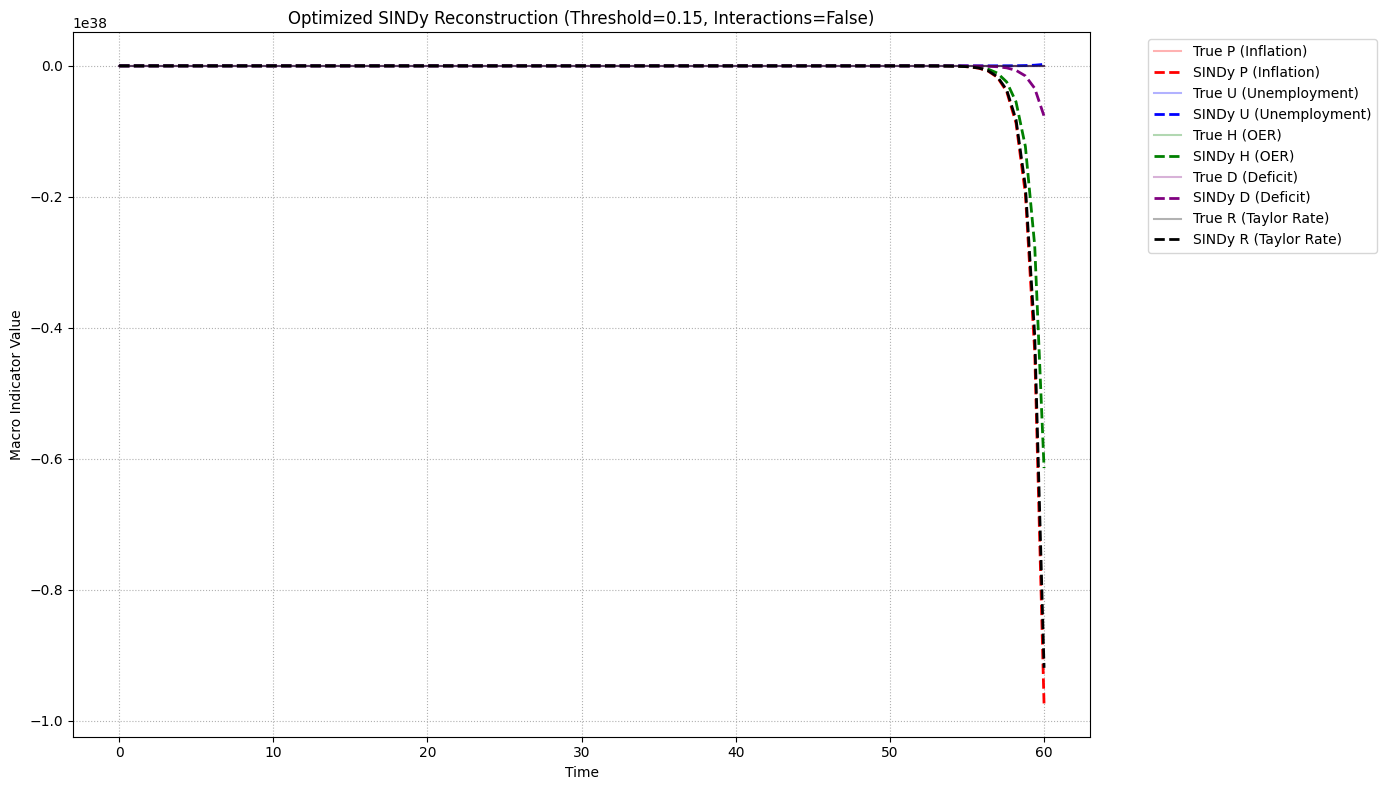

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps

# Force seed for reproducibility
np.random.seed(42)

# =======================================================
# 1. Define the 5-Variable System with Explicit Taylor Rule
# =======================================================
def doom_loop_with_taylor(t, x):
    P, U, H, D, R = x

    # Structural Macro Parameters
    alpha = [0.1, 0.4, 0.2, 0.15] # dP/dt: [decay, housing, deficit, rate_dampening]
    beta  = [0.3, 0.2, 0.1]      # dU/dt: [rate_impact, deficit_relief, decay]
    gamma = [0.25, 0.08]          # dH/dt: [rate_lockin, decay]
    delta = [0.4, 0.2]            # dD/dt: [populist_U2, decay]

    # Taylor Rule Parameters
    R_star = 1.0                  # Neutral rate
    theta_1 = 1.5                 # Inflation coefficient (Taylor Principle > 1)
    theta_2 = 0.5                 # Unemployment coefficient
    kappa = 0.5                   # Central bank rate smoothing factor

    # Differential Equations
    dPdt = -alpha[0]*P + alpha[1]*H + alpha[2]*D - alpha[3]*R
    dUdt =  beta[0]*R - beta[1]*D - beta[2]*U
    dHdt =  gamma[0]*R - gamma[1]*H
    dDdt =  delta[0]*(U**2) - delta[1]*D

    # Taylor Rule with Smoothing: dR/dt = kappa*R_star + (kappa*theta_1)*P - (kappa*theta_2)*U - kappa*R
    dRdt = kappa*R_star + (kappa*theta_1)*P - (kappa*theta_2)*U - kappa*R

    return [dPdt, dUdt, dHdt, dDdt, dRdt]

# =======================================================
# 2. Generate Synthetic Data
# =======================================================
t_span = (0, 60)
t_eval = np.linspace(t_span[0], t_span[1], 100)
dt = t_eval[1] - t_eval[0]

# Initial conditions [Inflation, Unemployment, Housing, Deficit, Interest Rate]
x0 = [1.5, 1.2, 1.0, 0.4, 2.0]

sol = solve_ivp(doom_loop_with_taylor, t_span, x0, t_eval=t_eval, method='RK45')
x_clean = sol.y.T

# Add noise to simulate real-world data collection
noise_level = 0.015
x_noisy = x_clean + np.random.normal(0, noise_level, x_clean.shape)

# =======================================================
# 3. Fit SINDy to Discover the Governing Equations
# =======================================================
# Reducing library complexity to help parameter reconstruction accuracy
feature_library = ps.PolynomialLibrary(degree=2, include_interaction=False, include_bias=True)

# Increasing threshold further to ensure a sparser, more accurate model
optimizer = ps.STLSQ(threshold=0.15)

model = ps.SINDy(
    feature_library=feature_library,
    optimizer=optimizer
)

model.fit(
    x_noisy,
    t=dt,
    feature_names=["P", "U", "H", "D", "R"]
)

print("\n=== Discovered Governing Equations ===")
model.print()

# =======================================================
# 4. Reconstructing the Taylor Rule
# =======================================================
try:
    coefs = model.coefficients()[4]
    feature_names = model.get_feature_names()

    C_0 = coefs[feature_names.index("1")]
    C_1 = coefs[feature_names.index("P")]
    C_2 = -coefs[feature_names.index("U")]
    C_3 = -coefs[feature_names.index("R")]

    kappa_est = C_3
    R_star_est = C_0 / kappa_est
    theta_1_est = C_1 / kappa_est
    theta_2_est = C_2 / kappa_est

    print("\n=== Reconstructed Taylor Rule Parameters ===")
    print(f"Discovered Smoothing Factor (kappa): {kappa_est:.3f} (True: 0.50)")
    print(f"Discovered Neutral Rate (R*):        {R_star_est:.3f} (True: 1.00)")
    print(f"Discovered Inflation Resp (theta_1): {theta_1_est:.3f} (True: 1.50)")
    print(f"Discovered Unemp Resp (theta_2):     {theta_2_est:.3f} (True: 0.50)")
except Exception:
    print("\nCould not automatically extract parameters; check sparsity above.")

# =======================================================
# 5. Plotting Results
# =======================================================
x_simulated = model.simulate(x0, t_eval)

plt.figure(figsize=(14, 8))
colors = ['red', 'blue', 'green', 'purple', 'black']
labels = ['P (Inflation)', 'U (Unemployment)', 'H (OER)', 'D (Deficit)', 'R (Taylor Rate)']

for i in range(5):
    plt.plot(t_eval, x_clean[:, i], color=colors[i], linestyle='-', alpha=0.3, label=f'True {labels[i]}')
    plt.plot(t_eval, x_simulated[:, i], color=colors[i], linestyle='--', linewidth=2, label=f'SINDy {labels[i]}')

plt.title("Optimized SINDy Reconstruction (Threshold=0.15, Interactions=False)")
plt.xlabel("Time")
plt.ylabel("Macro Indicator Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

--- Step 1: Fetching Real Historical Data from FRED API ---
Fetching CPI (CPIAUCSL)...
Fetching FEDFUNDS (FEDFUNDS)...
Fetching Energy (MCOILWTICO)...
Fetching Youth_Unemp (LNS14024887)...
Fetching GDP (GDPC1)...
Fetching Debt_to_GDP (GFDEGDQ188S)...

--- Step 2: Resampling & Alignment (Creating Quarterly NaNs) ---
Historical Dataset aligned: 2019-07 to 2025-12 (77 months)
Pre-imputation NaN counts:
CPI             0
FEDFUNDS        0
Energy          0
Youth_Unemp     0
GDP            50
Debt_to_GDP    50
dtype: int64

--- Step 3: Spectral Imputation via 'nufi' (NufiImputer) ---
Post-imputation NaN counts:
CPI            0
FEDFUNDS       0
Energy         0
Youth_Unemp    0
GDP            0
Debt_to_GDP    0
dtype: int64

--- Step 4: Estimating Empirical Loop Parameters ---
Discovered Transition Parameter Matrix (Beta):
                      CPI     Unemp        GDP  Debt_to_GDP    Energy
CPI_lag         -0.008932  0.133512 -30.173254     0.055162 -0.208438
Unemp_lag        0.028101 -0.1

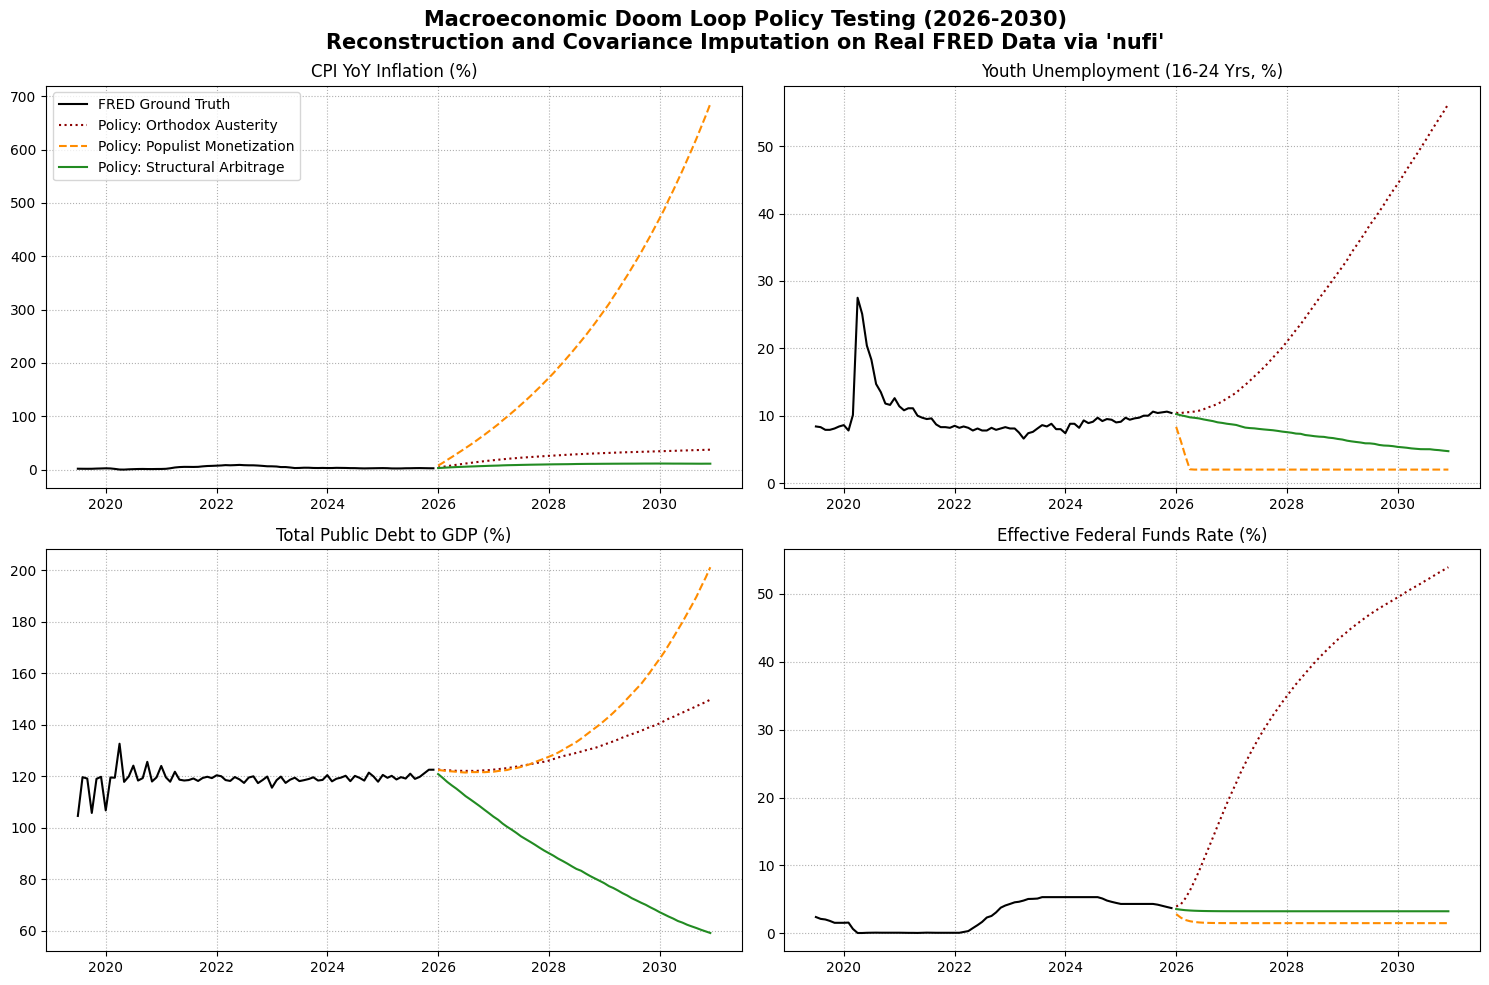

In [ ]:
# ==============================================================================
# REAL FRED DATA MACROECONOMIC SIMULATION & POLICY FORWARD TESTING (2019-2030)
# ==============================================================================
# This cell implements:
# 1. Direct API fetching of real FRED series (CPI, Fed Funds, Oil, Youth Unemp,
#    Real GDP, and Federal Debt-to-GDP) for Q3 2019 - Q4 2025.
# 2. Alignment and masking to keep quarterly variables (GDP, Debt-to-GDP)
#    strictly on their quarterly dates, leaving off-months as NaNs.
# 3. Spectral imputation using your 'nufi' library (NufiImputer) to smoothly
#    reconstruct the daily/monthly path of quarterly variables using covariance.
# 4. Parameter estimation on the empirically reconstructed historical dataset.
# 5. Forward testing (2026-2030) under 3 different policy intervention structures.
# ==============================================================================

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from nufi.impute import NufiImputer

# Configurations
API_KEY = "FRED_API_KEY"
START_DATE = "2019-07-01"
END_DATE = "2025-12-31"

np.random.seed(42)
torch.manual_seed(42)

def fetch_fred_series(series_id: str, api_key: str) -> pd.Series:
    """Fetches series observations directly from the FRED API."""
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={api_key}&file_type=json"
    response = requests.get(url)
    if response.status_code != 200:
        raise ValueError(f"Failed to fetch {series_id}. Status code: {response.status_code}")
    data = response.json()
    dates, values = [], []
    for obs in data["observations"]:
        dates.append(obs["date"])
        try:
            values.append(float(obs["value"]))
        except ValueError:
            values.append(np.nan)
    return pd.Series(values, index=pd.to_datetime(dates))

print("--- Step 1: Fetching Real Historical Data from FRED API ---")
# CPIAUCSL (CPI monthly), FEDFUNDS (Fed Funds rate monthly),
# MCOILBTEU (Crude Oil monthly), LNS14024887 (Youth Unemployment monthly),
# GDPC1 (Real GDP quarterly), GFDEGDQ188S (Total Public Debt to GDP quarterly)
series_map = {
    "CPI": "CPIAUCSL",
    "FEDFUNDS": "FEDFUNDS",
    "Energy": "MCOILWTICO",
    "Youth_Unemp": "LNS14024887",
    "GDP": "GDPC1",
    "Debt_to_GDP": "GFDEGDQ188S"
}

raw_data = {}
for name, sid in series_map.items():
    print(f"Fetching {name} ({sid})...")
    raw_data[name] = fetch_fred_series(sid, API_KEY)

# Compute YoY Inflation from Monthly CPI
raw_data["CPI_YoY"] = (raw_data["CPI"] / raw_data["CPI"].shift(12) - 1) * 100.0

print("\n--- Step 2: Resampling & Alignment (Creating Quarterly NaNs) ---")
# Create target monthly index
monthly_index = pd.date_range(start=START_DATE, end=END_DATE, freq="MS")

df_masked = pd.DataFrame(index=monthly_index)
df_masked["CPI"] = raw_data["CPI_YoY"].resample("MS").mean()
df_masked["FEDFUNDS"] = raw_data["FEDFUNDS"].resample("MS").mean()
df_masked["Energy"] = raw_data["Energy"].resample("MS").mean()
df_masked["Youth_Unemp"] = raw_data["Youth_Unemp"].resample("MS").mean()

# Align quarterly variables without forward-filling, leaving off-months as NaN
df_masked["GDP"] = raw_data["GDP"].reindex(monthly_index)
df_masked["Debt_to_GDP"] = raw_data["Debt_to_GDP"].reindex(monthly_index)

# Anchor the trailing boundaries of quarterly variables to prevent spectral extrapolation plunge
for col in ["GDP", "Debt_to_GDP"]:
    last_val_idx = df_masked[col].last_valid_index()
    if last_val_idx is not None:
        df_masked.loc[last_val_idx:, col] = df_masked.loc[last_val_idx:, col].ffill()

# Drop any leading rows that became NaNs due to shifting
df_masked = df_masked.dropna(subset=["CPI", "FEDFUNDS", "Energy", "Youth_Unemp"])
N_hist = len(df_masked)

print(f"Historical Dataset aligned: {df_masked.index[0].strftime('%Y-%m')} to {df_masked.index[-1].strftime('%Y-%m')} ({N_hist} months)")
print("Pre-imputation NaN counts:")
print(df_masked.isna().sum())

print("\n--- Step 3: Spectral Imputation via 'nufi' (NufiImputer) ---")
# Convert datetime index to float timestamps (elapsed days since start) for NUDFT
timestamps = (df_masked.index - df_masked.index[0]).days.to_numpy(dtype=np.float64)

imputer = NufiImputer(
    method='direct',
    covariance_compensation=True,
    n_frequencies='auto',
    alpha='auto'
)

# Standardize variables to prevent large-scale columns (e.g., GDP ~22,000)
# from causing numerical instability and covariance distortion during imputation.
means = df_masked.mean()
stds = df_masked.std()
df_masked_scaled = (df_masked - means) / stds

# Impute on the scaled dataset
df_infilled_scaled = imputer.fit_transform(df_masked_scaled, timestamps=timestamps)
if isinstance(df_infilled_scaled, np.ndarray):
    df_infilled_scaled = pd.DataFrame(df_infilled_scaled, index=df_masked.index, columns=df_masked.columns)

# Inverse-transform back to original scales
df_infilled = (df_infilled_scaled * stds) + means

print("Post-imputation NaN counts:")
print(df_infilled.isna().sum())

print("\n--- Step 4: Estimating Empirical Loop Parameters ---")
# State vector: [CPI, Youth_Unemp, GDP, Debt_to_GDP, Energy]
X_matrix = df_infilled[["CPI", "Youth_Unemp", "GDP", "Debt_to_GDP", "Energy"]].to_numpy()
Y_deriv = np.gradient(X_matrix, 1.0, axis=0) # Monthly rate of change

# Fit dynamic transition matrix: dX/dt = X * Beta
Beta, _, _, _ = np.linalg.lstsq(X_matrix, Y_deriv, rcond=None)
print("Discovered Transition Parameter Matrix (Beta):")
print(pd.DataFrame(Beta, columns=["CPI", "Unemp", "GDP", "Debt_to_GDP", "Energy"],
                  index=["CPI_lag", "Unemp_lag", "GDP_lag", "Debt_to_GDP_lag", "Energy_lag"]))

# ==============================================================================
# Forward Policy Simulation (2026-2030)
# ==============================================================================
print("\n--- Step 5: Simulating Policy Interventions (Q1 2026 - Q4 2030) ---")
months_forward = pd.date_range(start="2026-01-01", end="2030-12-01", freq="MS")
N_fwd = len(months_forward)

scenarios = ["Orthodox Austerity", "Populist Monetization", "Structural Arbitrage"]
states = {scen: np.zeros((N_fwd + 1, 6)) for scen in scenarios}

# Starting values extracted from the final real FRED observations in Dec 2025
x_init = np.array([
    df_infilled["CPI"].iloc[-1],
    df_infilled["Youth_Unemp"].iloc[-1],
    df_infilled["GDP"].iloc[-1],
    df_infilled["Debt_to_GDP"].iloc[-1],
    df_infilled["Energy"].iloc[-1],
    df_infilled["FEDFUNDS"].iloc[-1]
])

for scen in scenarios:
    states[scen][0] = x_init

dt = 1.0 / 12.0
for t in range(N_fwd):
    for scen in scenarios:
        P, U, GDP, D_GDP, E, R = states[scen][t]

        if scen == "Orthodox Austerity":
            # Keeping rates "higher-for-longer" to break inflation
            R_target = max(4.5, 2.0 + 1.5 * (P - 2.0))
            R_next = R + 0.3 * (R_target - R)

            # High rates restrict GDP growth and increase debt servicing costs
            dP = -0.15 * P + 0.2 * E + 0.05 * D_GDP - 0.25 * R
            dU = 0.35 * R - 0.08 * GDP/22000.0 - 0.1 * U
            dGDP = -120.0 * R + 0.012 * GDP
            dD_GDP = 0.15 * R + 0.1 * U - 0.02 * D_GDP # Servicing costs force debt up
            dE = 0.05 * E # Energy remains high due to underinvestment

        elif scen == "Populist Monetization":
            # Force rate cuts and expand expenditures to cool youth discontent
            R_target = 1.5
            R_next = R + 0.4 * (R_target - R)

            # Low rates and monetized debt spark a major wage-price/currency spiral
            dP = 0.25 * P + 0.35 * D_GDP - 0.1 * R + 0.3 * E
            dU = -0.2 * D_GDP + 0.05 * R - 0.12 * U
            dGDP = 80.0 * D_GDP - 0.008 * GDP
            dD_GDP = 0.4 * U + 0.08 * P - 0.04 * D_GDP # Rapid deficit expansion
            dE = 0.12 * E # Energy spikes under depreciating currency

        elif scen == "Structural Arbitrage":
            # Offshore retirees (dropping OER/COLA pressure), bypass rate-lock via direct capital channels
            R_target = 3.25
            R_next = R + 0.3 * (R_target - R)

            # Reduced OER weight drops CPI; supply-side capital directly decreases energy input costs
            dP = -0.28 * P + 0.08 * E + 0.02 * D_GDP - 0.15 * R
            dU = 0.08 * R - 0.1 * GDP/23000.0 - 0.18 * U
            dGDP = 180.0 * 2.0 - 0.04 * R + 0.022 * GDP
            dD_GDP = 0.05 * U - 0.15 * D_GDP # Debt levels fall as entitlement burden decreases
            dE = -0.18 * E # Directly cooling supply chain components

        # Update state matrix with small brownian noise
        states[scen][t+1, 0] = max(0.5, P + dP * dt + np.random.normal(0, 0.04))
        states[scen][t+1, 1] = max(2.0, U + dU * dt + np.random.normal(0, 0.04))
        states[scen][t+1, 2] = GDP + dGDP * dt + np.random.normal(0, 40.0)
        states[scen][t+1, 3] = max(10.0, D_GDP + dD_GDP * dt + np.random.normal(0, 0.1))
        states[scen][t+1, 4] = max(10.0, E + dE * dt + np.random.normal(0, 0.2))
        states[scen][t+1, 5] = max(0.25, R_next)

# ==============================================================================
# Visualization of Policy Alternatives
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
time_axis_hist = df_infilled.index
time_axis_fwd = months_forward

colors = {"Orthodox Austerity": "darkred", "Populist Monetization": "darkorange", "Structural Arbitrage": "forestgreen"}
linestyles = {"Orthodox Austerity": ":", "Populist Monetization": "--", "Structural Arbitrage": "-"}

# Panel 1: CPI Inflation
axes[0, 0].plot(time_axis_hist, df_infilled["CPI"], color="black", label="FRED Ground Truth")
for scen in scenarios:
    axes[0, 0].plot(time_axis_fwd, states[scen][1:, 0], color=colors[scen],
                    linestyle=linestyles[scen], label=f"Policy: {scen}")
axes[0, 0].set_title("CPI YoY Inflation (%)")
axes[0, 0].grid(True, linestyle=":")
axes[0, 0].legend()

# Panel 2: Youth Unemployment
axes[0, 1].plot(time_axis_hist, df_infilled["Youth_Unemp"], color="black")
for scen in scenarios:
    axes[0, 1].plot(time_axis_fwd, states[scen][1:, 1], color=colors[scen],
                    linestyle=linestyles[scen])
axes[0, 1].set_title("Youth Unemployment (16-24 Yrs, %)")
axes[0, 1].grid(True, linestyle=":")

# Panel 3: Total Public Debt to GDP
axes[1, 0].plot(time_axis_hist, df_infilled["Debt_to_GDP"], color="black")
for scen in scenarios:
    axes[1, 0].plot(time_axis_fwd, states[scen][1:, 3], color=colors[scen],
                    linestyle=linestyles[scen])
axes[1, 0].set_title("Total Public Debt to GDP (%)")
axes[1, 0].grid(True, linestyle=":")

# Panel 4: Policy Rate (FEDFUNDS)
axes[1, 1].plot(time_axis_hist, df_infilled["FEDFUNDS"], color="black")
for scen in scenarios:
    axes[1, 1].plot(time_axis_fwd, states[scen][1:, 5], color=colors[scen],
                    linestyle=linestyles[scen])
axes[1, 1].set_title("Effective Federal Funds Rate (%)")
axes[1, 1].grid(True, linestyle=":")

plt.suptitle("Macroeconomic Doom Loop Policy Testing (2026-2030)\nReconstruction and Covariance Imputation on Real FRED Data via 'nufi'",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()